# 05 — Feature Importance & SHAP Analysis
### PMSM Winding Process — Quality Prediction Project
---
**Goal:** Identify which process signals most strongly predict each quality outcome.  
**Methods:** SHAP values · Permutation importance · Signal group analysis  
**Key question:** Which signal group — tension, power, or temperature — drives quality most?


## 1. Imports & Config

In [6]:
import os
os.chdir(os.path.dirname(os.path.abspath('05_FeatureImportance.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\PMSM Winding Project\pmsm-winding-quality-prediction\notebooks


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

import shap
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 12,
})

os.makedirs('../results/plots', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


In [12]:
def get_shap_explainer(model):
    """Compatibility fix for XGBoost + SHAP version mismatch."""
    try:
        return shap.TreeExplainer(model)
    except (ValueError, Exception):
        booster = model.get_booster()
        booster.attrs['best_iteration'] = str(booster.num_boosted_rounds() - 1)
        import re
        config = booster.save_config()
        config = re.sub(r'"base_score":"[^"]*"', '"base_score":"0.5"', config)
        booster.load_config(config)
        return shap.TreeExplainer(booster)

## 2. Load Data & Models

In [13]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

with open('../src/feature_list.txt') as f:
    FEATURES = [line.strip() for line in f.readlines()]

TARGETS_REG = ['slot_fill_factor_pct', 'winding_resistance_mOhm',
               'insulation_integrity_score', 'process_stability_index']
TARGET_CLF  = 'insulation_failure'

X_train = train[FEATURES];  X_val = val[FEATURES];  X_test = test[FEATURES]
y_train = train[TARGETS_REG + [TARGET_CLF]]
y_val   = val[TARGETS_REG + [TARGET_CLF]]
y_test  = test[TARGETS_REG + [TARGET_CLF]]

X_full = pd.concat([X_train, X_val, X_test]).reset_index(drop=True)
y_full = pd.concat([y_train, y_val, y_test]).reset_index(drop=True)

print(f"Full dataset: {X_full.shape}")
print(f"Features: {len(FEATURES)}")


Full dataset: (500, 44)
Features: 44


## 3. Retrain XGBoost Models on Full Dataset for SHAP

In [16]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

rf_models = {}
print("Training Random Forest models for SHAP analysis...")
for target in TARGETS_REG:
    model = RandomForestRegressor(
        n_estimators=200, max_depth=12,
        min_samples_leaf=3, random_state=SEED, n_jobs=-1)
    model.fit(X_full, y_full[target])
    rf_models[target] = model
    print(f"  {target} — done")

# Classifier
clf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=3, class_weight='balanced',
    random_state=SEED, n_jobs=-1)
clf_model.fit(X_full, y_full[TARGET_CLF])
print(f"  {TARGET_CLF} (classifier) — done")

Training Random Forest models for SHAP analysis...
  slot_fill_factor_pct — done
  winding_resistance_mOhm — done
  insulation_integrity_score — done
  process_stability_index — done
  insulation_failure (classifier) — done


## 4. SHAP Values — Primary Target: Slot Fill Factor

In [17]:
target = 'slot_fill_factor_pct'
model  = rf_models[target]

explainer   = get_shap_explainer(model)
shap_values = explainer.shap_values(X_full)

shap_df = pd.DataFrame(shap_values, columns=FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f"Top 15 features by mean |SHAP| for: {target}")
print(mean_abs_shap.head(15).round(4).to_string())


Top 15 features by mean |SHAP| for: slot_fill_factor_pct
log_slot_density_idx         9.2084
slot_density_idx             8.8296
tension_mean_N               0.1167
log_tension_slope_start      0.1061
wire_tension_N               0.1000
slot_depth_mm                0.0915
tension_slope_start          0.0905
tension_peak_N               0.0849
winding_speed_rpm            0.0563
mech_load_idx                0.0519
tension_area_Nmm             0.0495
log_tension_area_Nmm         0.0479
back_tension_N               0.0419
tension_variability_ratio    0.0407
back_tension_ratio           0.0319


### 4.1 SHAP Bar Plot — Top 15 Features

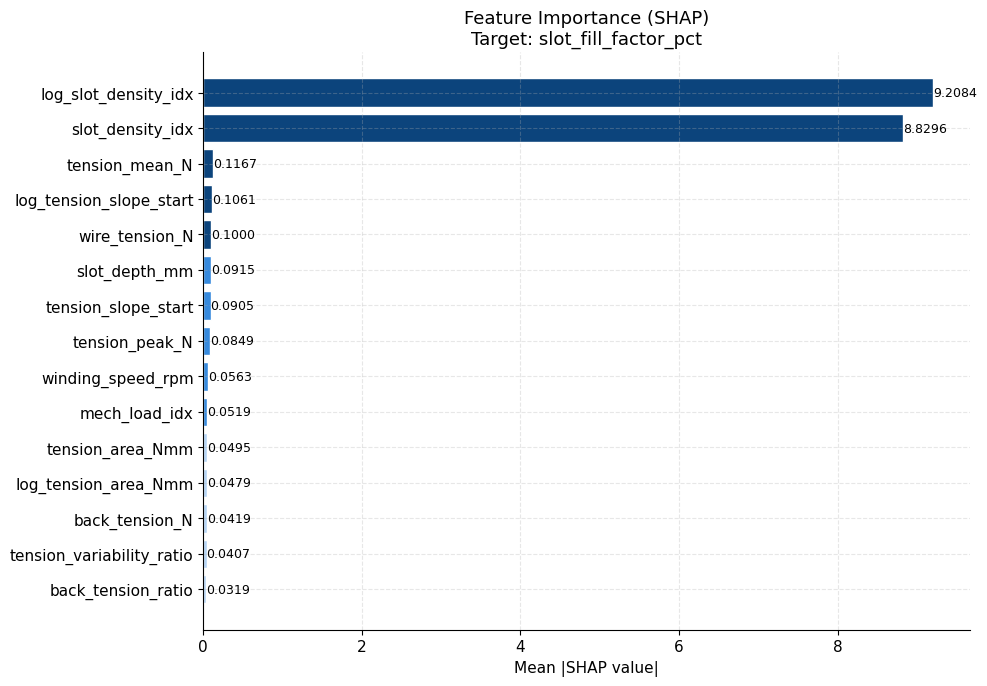

Saved: 21_shap_bar_slot_fill.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

top15 = mean_abs_shap.head(15)
colors_bar = ['#0C447C' if i < 5 else '#378ADD' if i < 10 else '#B5D4F4'
              for i in range(len(top15))]

bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colors_bar[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Feature Importance (SHAP)\nTarget: {target}', fontsize=13)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/21_shap_bar_slot_fill.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 21_shap_bar_slot_fill.png")


### 4.2 SHAP Beeswarm Plot

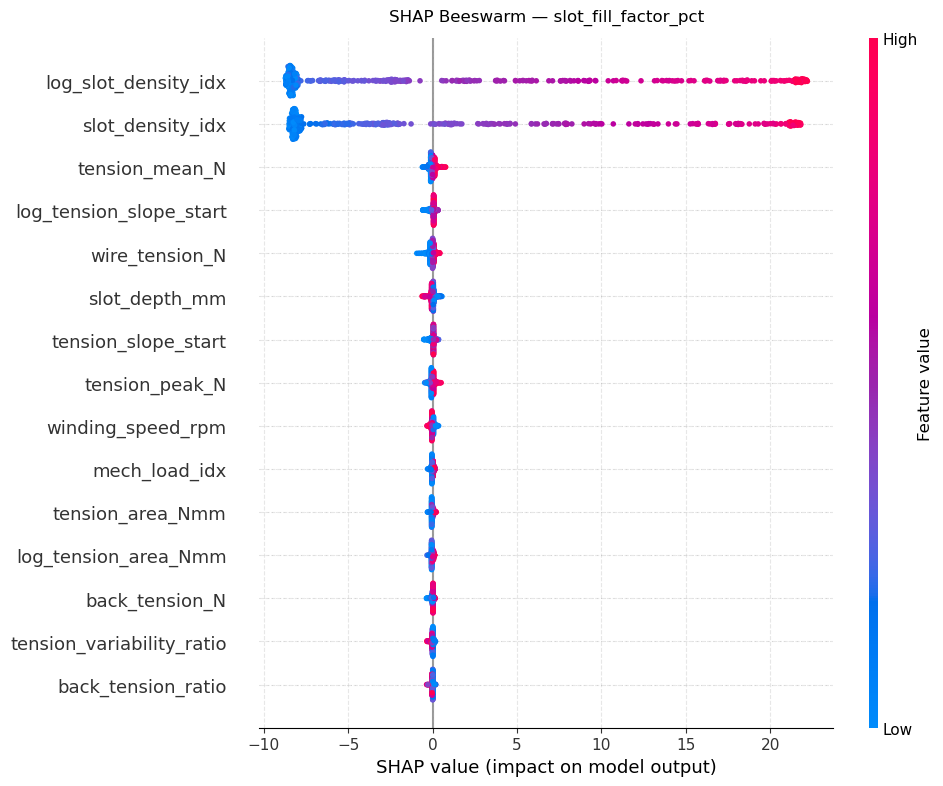

Saved: 22_shap_beeswarm_slot_fill.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_full,
    feature_names=FEATURES,
    max_display=15,
    show=False,
    plot_size=None
)
plt.title(f'SHAP Beeswarm — {target}', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/plots/22_shap_beeswarm_slot_fill.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 22_shap_beeswarm_slot_fill.png")


## 5. SHAP — Insulation Failure (Classifier)

In [21]:
clf_explainer   = shap.TreeExplainer(clf_model)
clf_shap_values_raw = clf_explainer.shap_values(X_full)

# Random Forest classifier returns shap values for both classes
# We take class 1 (failure) — that's what we care about
clf_shap_values = clf_shap_values_raw[:, :, 1]

clf_shap_df      = pd.DataFrame(clf_shap_values, columns=FEATURES)
clf_mean_abs     = clf_shap_df.abs().mean().sort_values(ascending=False)

print(f"Top 15 features by mean |SHAP| for: {TARGET_CLF}")
print(clf_mean_abs.head(15).round(4).to_string())

Top 15 features by mean |SHAP| for: insulation_failure
temp_max_C                  0.0498
winding_temperature_C       0.0341
log_temp_time_above_60s     0.0299
temp_time_above_60s         0.0272
slot_depth_mm               0.0173
power_instability_idx       0.0169
log_thermal_stress_idx      0.0136
speed_tension_product       0.0123
thermal_stress_idx          0.0112
temp_gradient_C_per_turn    0.0081
log_tension_slope_start     0.0080
wire_tension_N              0.0079
spindle_torque_Nm           0.0074
log_tension_area_Nmm        0.0070
slot_density_idx            0.0069


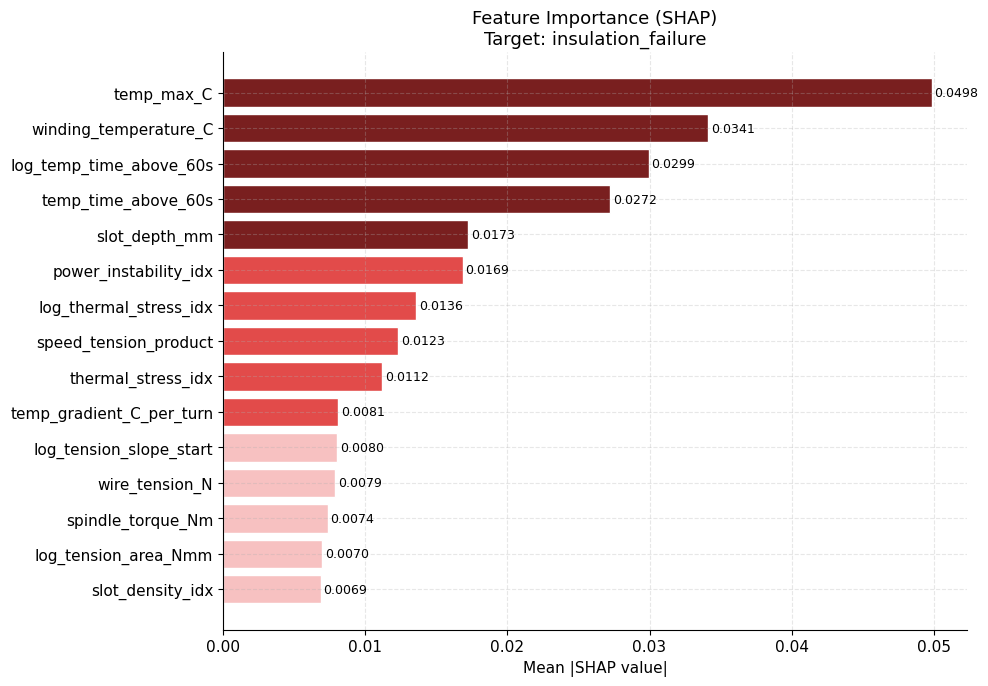

Saved: 23_shap_bar_failure.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
top15_clf = clf_mean_abs.head(15)
colors_clf = ['#791F1F' if i < 5 else '#E24B4A' if i < 10 else '#F7C1C1'
              for i in range(len(top15_clf))]
bars = ax.barh(top15_clf.index[::-1], top15_clf.values[::-1],
               color=colors_clf[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Feature Importance (SHAP)\nTarget: {TARGET_CLF}', fontsize=13)
for bar, val in zip(bars, top15_clf.values[::-1]):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/23_shap_bar_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 23_shap_bar_failure.png")


## 6. Signal Group Importance Analysis

In [23]:
SIGNAL_GROUPS = {
    'Process params':      [f for f in FEATURES if f in [
        'winding_speed_rpm','wire_tension_N','wire_diameter_mm','num_turns',
        'slot_width_mm','slot_depth_mm','insulation_thickness_mm',
        'winding_temperature_C','spindle_torque_Nm','back_tension_N']],
    'Tension signals':     [f for f in FEATURES if 'tension' in f and 'log' not in f
                            and f not in ['wire_tension_N','back_tension_N']],
    'Power signals':       [f for f in FEATURES if 'power' in f and 'log' not in f],
    'Temperature signals': [f for f in FEATURES if 'temp' in f and 'log' not in f],
    'Derived features':    [f for f in FEATURES if any(x in f for x in
                            ['variability','dynamic_range','per_turn','instability',
                             'thermal_stress','slot_density','mech_load',
                             'speed_tension','back_tension_ratio'])],
    'Log-transformed':     [f for f in FEATURES if f.startswith('log_')],
    'Material dummies':    [f for f in FEATURES if f.startswith('material_')],
}

print("Features per group:")
for g, feats in SIGNAL_GROUPS.items():
    print(f"  {g:<22}: {len(feats)} features")


Features per group:
  Process params        : 10 features
  Tension signals       : 9 features
  Power signals         : 7 features
  Temperature signals   : 4 features
  Derived features      : 15 features
  Log-transformed       : 9 features
  Material dummies      : 3 features


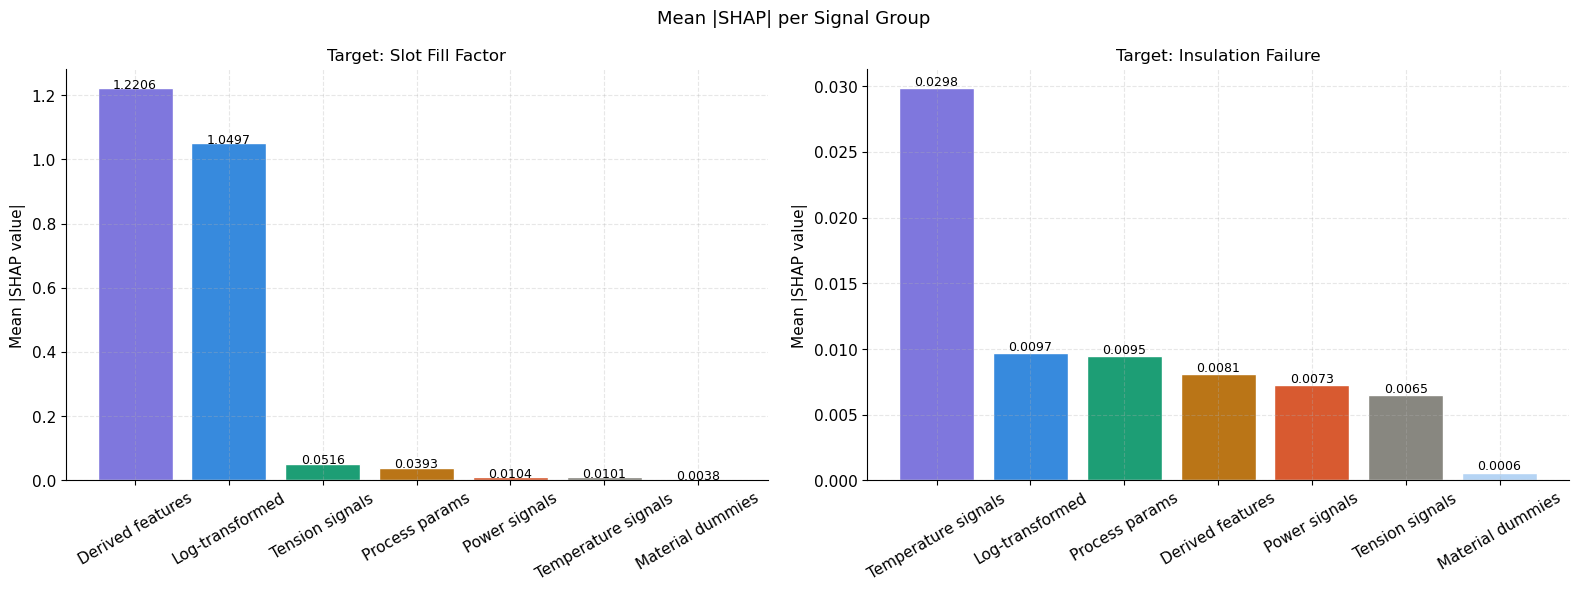

Saved: 24_shap_group_importance.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean |SHAP| per Signal Group', fontsize=13)

colors_g = ['#7F77DD','#378ADD','#1D9E75','#BA7517','#D85A30','#888780','#B5D4F4']

for ax, (target_name, shap_vals_arr, label) in zip(axes, [
    (target,     shap_values,     'Slot Fill Factor'),
    (TARGET_CLF, clf_shap_values, 'Insulation Failure'),
]):
    s_df = pd.DataFrame(shap_vals_arr, columns=FEATURES)
    group_means = {}
    for gname, gfeats in SIGNAL_GROUPS.items():
        valid = [f for f in gfeats if f in s_df.columns]
        if valid:
            group_means[gname] = s_df[valid].abs().mean().mean()

    sorted_groups = dict(sorted(group_means.items(), key=lambda x: x[1], reverse=True))
    bars = ax.bar(list(sorted_groups.keys()), list(sorted_groups.values()),
                  color=colors_g[:len(sorted_groups)], edgecolor='white')
    ax.set_title(f'Target: {label}')
    ax.set_ylabel('Mean |SHAP value|')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, sorted_groups.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/24_shap_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 24_shap_group_importance.png")


## 7. SHAP Across All Regression Targets

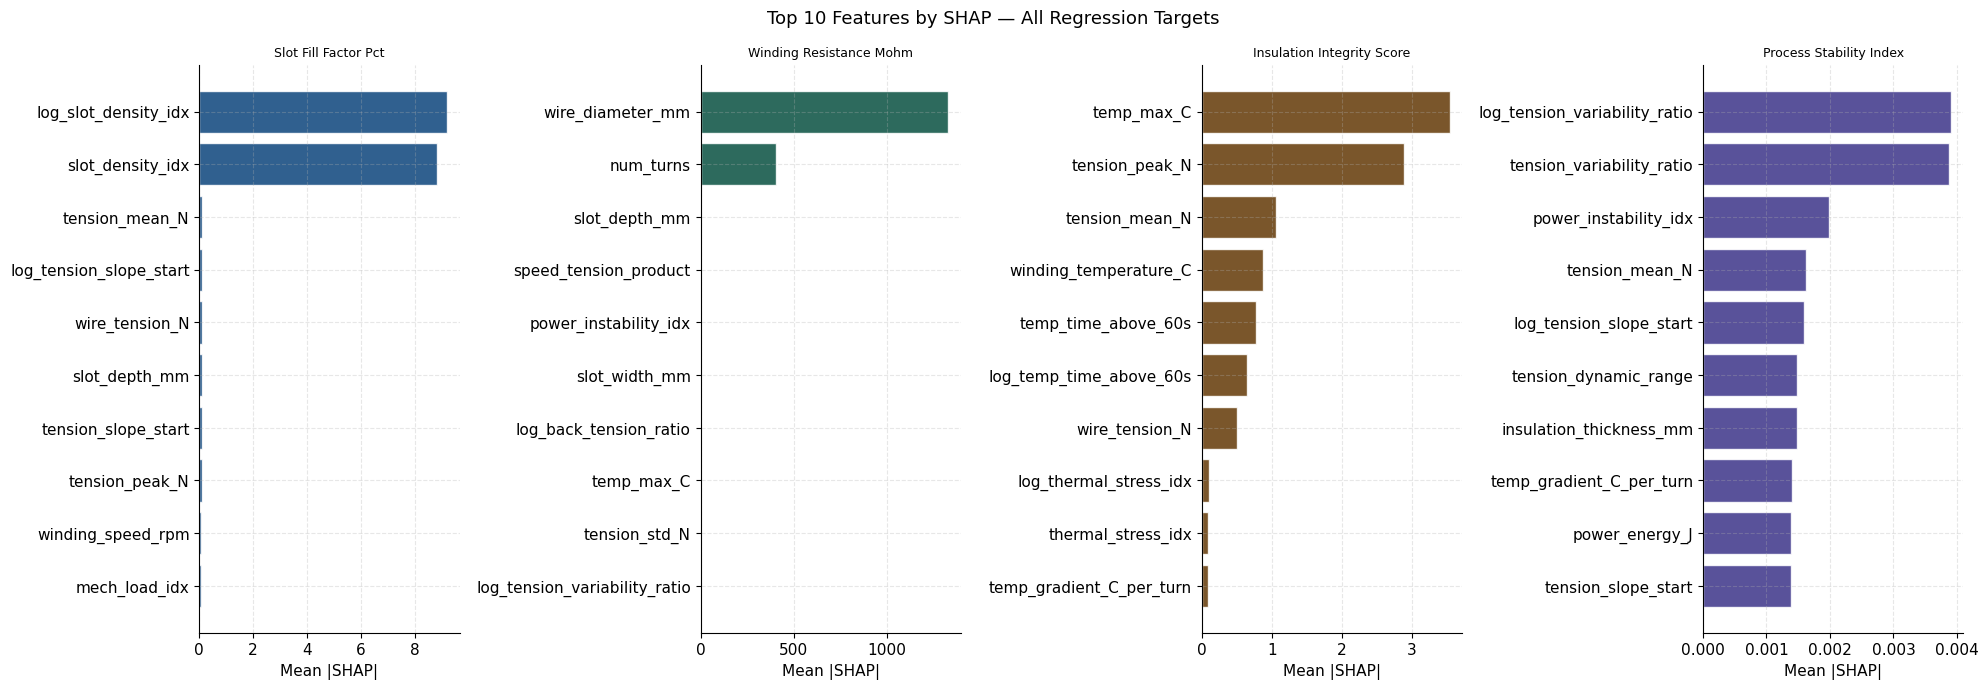

Saved: 25_shap_all_targets.png


In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.suptitle('Top 10 Features by SHAP — All Regression Targets', fontsize=13)

target_colors = ['#0C447C', '#085041', '#633806', '#3C3489']

for ax, target, color in zip(axes, TARGETS_REG, target_colors):
    exp   = shap.TreeExplainer(rf_models[target])
    sv    = exp.shap_values(X_full)
    sv_df = pd.DataFrame(sv, columns=FEATURES)
    top10 = sv_df.abs().mean().sort_values(ascending=True).tail(10)

    ax.barh(top10.index, top10.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(target.replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('Mean |SHAP|')

plt.tight_layout()
plt.savefig('../results/plots/25_shap_all_targets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 25_shap_all_targets.png")

## 8. Top Feature Deep Dive — SHAP Dependence Plot

Top feature for slot_fill_factor_pct: log_slot_density_idx


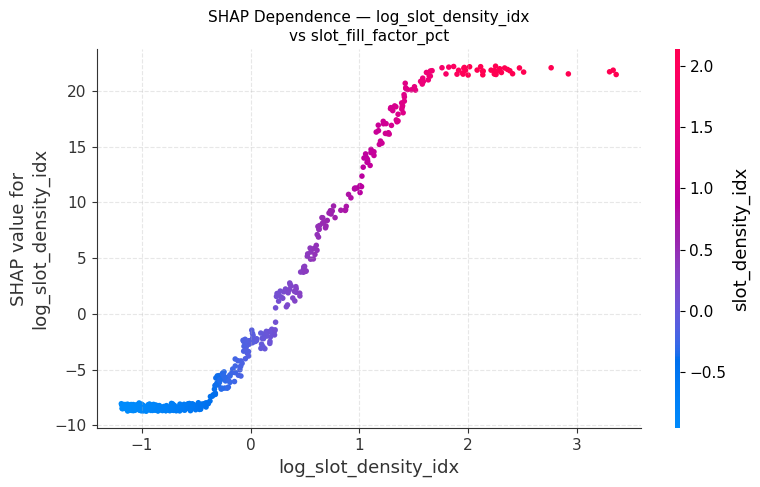

Saved: 26_shap_dependence.png


In [28]:
# Pick the top feature for slot fill factor
top_feature = mean_abs_shap.index[0]
print(f"Top feature for slot_fill_factor_pct: {top_feature}")

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feature, shap_values, X_full,
    feature_names=FEATURES,
    ax=ax, show=False
)
ax.set_title(f'SHAP Dependence — {top_feature}\nvs slot_fill_factor_pct', fontsize=11)
plt.tight_layout()
plt.savefig('../results/plots/26_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: 26_shap_dependence.png")


## 9. Save Feature Importance Rankings

In [30]:
importance_rows = []
for target in TARGETS_REG:
    exp   = shap.TreeExplainer(rf_models[target])
    sv    = exp.shap_values(X_full)
    sv_df = pd.DataFrame(sv, columns=FEATURES)
    ranked = sv_df.abs().mean().sort_values(ascending=False).reset_index()
    ranked.columns = ['feature', 'mean_abs_shap']
    ranked['target'] = target
    ranked['rank'] = range(1, len(ranked) + 1)
    importance_rows.append(ranked)

# Classifier
sv_df_clf = pd.DataFrame(clf_shap_values, columns=FEATURES)
ranked_clf = sv_df_clf.abs().mean().sort_values(ascending=False).reset_index()
ranked_clf.columns = ['feature', 'mean_abs_shap']
ranked_clf['target'] = TARGET_CLF
ranked_clf['rank'] = range(1, len(ranked_clf) + 1)
importance_rows.append(ranked_clf)

importance_df = pd.concat(importance_rows, ignore_index=True)
importance_df.to_csv('../results/feature_importance_shap.csv', index=False)
print(f"Saved: ../results/feature_importance_shap.csv")
print(f"Rows: {len(importance_df)}")
print()
print("Top 5 features per target:")
for target in TARGETS_REG + [TARGET_CLF]:
    top5 = importance_df[importance_df['target'] == target].head(5)['feature'].tolist()
    print(f"  {target}: {', '.join(top5)}")


Saved: ../results/feature_importance_shap.csv
Rows: 220

Top 5 features per target:
  slot_fill_factor_pct: log_slot_density_idx, slot_density_idx, tension_mean_N, log_tension_slope_start, wire_tension_N
  winding_resistance_mOhm: wire_diameter_mm, num_turns, slot_depth_mm, speed_tension_product, power_instability_idx
  insulation_integrity_score: temp_max_C, tension_peak_N, tension_mean_N, winding_temperature_C, temp_time_above_60s
  process_stability_index: log_tension_variability_ratio, tension_variability_ratio, power_instability_idx, tension_mean_N, log_tension_slope_start
  insulation_failure: temp_max_C, winding_temperature_C, log_temp_time_above_60s, temp_time_above_60s, slot_depth_mm


## 10. Feature Importance Summary

In [31]:
print("=" * 60)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 60)
print()
print("TOP PREDICTIVE FEATURES:")

for target in TARGETS_REG + [TARGET_CLF]:
    top3 = importance_df[importance_df['target']==target].head(3)['feature'].tolist()
    print(f"  {target:<35}: {', '.join(top3)}")

print()
print("SIGNAL GROUP RANKING (for slot_fill_factor_pct):")
s_df2 = pd.DataFrame(shap_values, columns=FEATURES)
group_rank = {}
for gname, gfeats in SIGNAL_GROUPS.items():
    valid = [f for f in gfeats if f in s_df2.columns]
    if valid:
        group_rank[gname] = s_df2[valid].abs().mean().mean()
for i, (g, v) in enumerate(sorted(group_rank.items(), key=lambda x: -x[1]), 1):
    print(f"  {i}. {g:<25}: mean |SHAP| = {v:.5f}")

print()
print("FILES SAVED:")
print("  ../results/feature_importance_shap.csv")
print("  ../results/plots/21_shap_bar_slot_fill.png")
print("  ../results/plots/22_shap_beeswarm_slot_fill.png")
print("  ../results/plots/23_shap_bar_failure.png")
print("  ../results/plots/24_shap_group_importance.png")
print("  ../results/plots/25_shap_all_targets.png")
print("  ../results/plots/26_shap_dependence.png")
print()
print("DAY 2 COMPLETE → Next: Day 3 — inline_monitor.py + README")


FEATURE IMPORTANCE SUMMARY

TOP PREDICTIVE FEATURES:
  slot_fill_factor_pct               : log_slot_density_idx, slot_density_idx, tension_mean_N
  winding_resistance_mOhm            : wire_diameter_mm, num_turns, slot_depth_mm
  insulation_integrity_score         : temp_max_C, tension_peak_N, tension_mean_N
  process_stability_index            : log_tension_variability_ratio, tension_variability_ratio, power_instability_idx
  insulation_failure                 : temp_max_C, winding_temperature_C, log_temp_time_above_60s

SIGNAL GROUP RANKING (for slot_fill_factor_pct):
  1. Derived features         : mean |SHAP| = 1.22057
  2. Log-transformed          : mean |SHAP| = 1.04971
  3. Tension signals          : mean |SHAP| = 0.05161
  4. Process params           : mean |SHAP| = 0.03929
  5. Power signals            : mean |SHAP| = 0.01035
  6. Temperature signals      : mean |SHAP| = 0.01014
  7. Material dummies         : mean |SHAP| = 0.00382

FILES SAVED:
  ../results/feature_importanc